# Financial Statement Analysis: 3-Statement Model

## Project Overview
This notebook builds a complete three-statement financial model using SQL as the primary analysis engine. The model integrates the income statement, balance sheet, and cash flow statement into a single analytical framework.

## Model Components
1. **Income Statement**: Revenue, net income
2. **Balance Sheet**: Assets, liabilities, shareholders' equity with validation
3. **Cash Flow Statement**: Derived from balance sheet changes using SQL window functions

## Data Source
Real SEC XBRL data from NVIDIA's 10-K and 10-Q filings via the `edgar` Python library. The data includes the most recent filings available. For other companies, change the ticker in Cell 5.

## Important Note: This is a Template, Not Company-Specific
**NVIDIA is used solely as an illustrative example.** This model is designed to be company-agnostic and can be applied to any publicly traded company by swapping the data source.

**Compatibility Note: The SQL queries work for ANY company as long as the column names match the edgartools output structure.**

## SEC Identity Requirement
The SEC requires all automated requests to identify the user. Run Cell 3 with your email address before downloading data.

## Technical Requirements
- edgartools, pandas, matplotlib, plotly, jupysql (installed automatically in Cell 2)`

In [8]:
# Install required packages
!pip install edgartools pandas matplotlib plotly jupysql
print("Packages installed")

Packages installed


In [7]:
# Set SEC identity (required by law)
from edgar import set_identity
set_identity("Research Analyst enterprise.blaise@gmail.com")
print("SEC identity set")

SEC identity set


In [9]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from edgar import Company
print("Libraries imported")

Libraries imported


In [10]:
# Download NVIDIA financial data from SEC
company_ticker = "NVDA"
company_name = "NVIDIA Corporation"
print(f"Downloading data for {company_name}...")

company = Company(company_ticker)
income_df = company.income_statement().to_dataframe()
balance_df = company.balance_sheet().to_dataframe()
cashflow_df = company.cash_flow_statement().to_dataframe()

print(f"Income: {len(income_df)} rows, Balance: {len(balance_df)} rows, Cash Flow: {len(cashflow_df)} rows")

Income: 25 rows, Balance: 35 rows, Cash Flow: 43 rows


In [11]:
# Create SQL database and load data
conn = sqlite3.connect('sec_financials.db')
income_df.to_sql('income_statement_raw', conn, if_exists='replace', index=False)
balance_df.to_sql('balance_sheet_raw', conn, if_exists='replace', index=False)
cashflow_df.to_sql('cash_flow_raw', conn, if_exists='replace', index=False)

%load_ext sql
%sql sqlite:///sec_financials.db
print("Database created")

Connecting to 'sqlite:///sec_financials.db'

Database created


In [12]:
# Check column names and available labels (needed for mapping to cash flow statement)
print("=== COLUMN STRUCTURE ===")
print("Income columns:", income_df.columns.tolist())
print("Balance columns:", balance_df.columns.tolist())

print("\n=== INCOME STATEMENT LABELS ===")
print(income_df['label'].tolist())

print("\n=== BALANCE SHEET LABELS ===")
print(balance_df['label'].tolist())

print("\n=== DETAILED BALANCE SHEET LINE ITEMS NEEDED FOR CASH FLOW ===")
cash_labels = ['Cash', 'Cash and Cash Equivalents', 'Cash and Cash Equivalents, at Carrying Value']
ar_labels = ['Accounts Receivable', 'Accounts Receivable, Net', 'Accounts Receivable, after Allowance for Credit Loss, Current']
inv_labels = ['Inventory', 'Inventory, Net']
ap_labels = ['Accounts Payable', 'Accounts Payable, Current']
ppe_labels = ['Property, Plant and Equipment', 'Property, Plant and Equipment, Net', 'PPE']

print("Checking for required cash flow components in balance sheet...")
for label in cash_labels:
    if label in balance_df['label'].tolist():
        print(f"  Found Cash label: '{label}'")
        break
else:
    print("No Cash label found. Available cash-related labels:")
    cash_matches = [l for l in balance_df['label'].tolist() if 'cash' in l.lower()]
    for match in cash_matches:
        print(f"      - {match}")

for label in ar_labels:
    if label in balance_df['label'].tolist():
        print(f"  Found Accounts Receivable label: '{label}'")
        break
else:
    print("No Accounts Receivable label found. Available AR-related labels:")
    ar_matches = [l for l in balance_df['label'].tolist() if 'receivable' in l.lower()]
    for match in ar_matches:
        print(f"      - {match}")

for label in inv_labels:
    if label in balance_df['label'].tolist():
        print(f"  Found Inventory label: '{label}'")
        break
else:
    print("No Inventory label found. Available inventory-related labels:")
    inv_matches = [l for l in balance_df['label'].tolist() if 'inventory' in l.lower()]
    for match in inv_matches:
        print(f"      - {match}")

for label in ap_labels:
    if label in balance_df['label'].tolist():
        print(f"  Found Accounts Payable label: '{label}'")
        break
else:
    print("No Accounts Payable label found. Available AP-related labels:")
    ap_matches = [l for l in balance_df['label'].tolist() if 'payable' in l.lower()]
    for match in ap_matches:
        print(f"      - {match}")

for label in ppe_labels:
    if label in balance_df['label'].tolist():
        print(f"  Found PPE label: '{label}'")
        break
else:
    print("No PPE label found. Available PPE-related labels:")
    ppe_matches = [l for l in balance_df['label'].tolist() if 'property' in l.lower() or 'plant' in l.lower()]
    for match in ppe_matches:
        print(f"      - {match}")

print("\n=== RAW BALANCE SHEET PREVIEW ===")
print(balance_df.head(3))

=== COLUMN STRUCTURE ===
Income columns: ['label', 'depth', 'is_abstract', 'is_total', 'section', 'confidence', 'FY 2026', 'FY 2025', 'FY 2024', 'FY 2023']
Balance columns: ['label', 'depth', 'is_abstract', 'is_total', 'section', 'confidence', 'FY 2026', 'FY 2025', 'FY 2024', 'FY 2023']

=== INCOME STATEMENT LABELS ===
['Total Revenue', 'Cost of Revenue', 'Gross Profit', 'Operating expenses:', 'Research and Development Expense', 'Operating Expenses', 'Selling, General and Administrative Expense', 'Operating Income (Loss)', 'Other Nonoperating Income (Expense)', 'Income (Loss) from Continuing Operations before Income Taxes, Noncontrolling Interest', 'Income Tax Expense (Benefit)', 'Net Income (Loss) Attributable to Parent', 'Earnings Per Share, Basic', 'Earnings Per Share, Diluted', 'Weighted Average Number of Shares Outstanding, Basic', 'Weighted Average Number of Shares Outstanding, Diluted', 'Interest Expense (non-operating)', 'Additional Financial Items', 'Amortization of Intangible

In [13]:
%%sql
-- Create unified financial facts table
DROP TABLE IF EXISTS financial_facts;

-- Income Statement: Total Revenue
CREATE TABLE financial_facts AS
SELECT 'IS' as statement_type, 'FY 2026' as fiscal_year, 'FY' as fiscal_period, 'Total Revenue' as fact_name, [FY 2026] as fact_value
FROM income_statement_raw WHERE label = 'Total Revenue'
UNION ALL
SELECT 'IS', 'FY 2025', 'FY', 'Total Revenue', [FY 2025]
FROM income_statement_raw WHERE label = 'Total Revenue'
UNION ALL
SELECT 'IS', 'FY 2024', 'FY', 'Total Revenue', [FY 2024]
FROM income_statement_raw WHERE label = 'Total Revenue'
UNION ALL
SELECT 'IS', 'FY 2023', 'FY', 'Total Revenue', [FY 2023]
FROM income_statement_raw WHERE label = 'Total Revenue'

UNION ALL

-- Income Statement: Net Income
SELECT 'IS', 'FY 2026', 'FY', 'Net Income', [FY 2026]
FROM income_statement_raw WHERE label = 'Net Income (Loss) Attributable to Parent'
UNION ALL
SELECT 'IS', 'FY 2025', 'FY', 'Net Income', [FY 2025]
FROM income_statement_raw WHERE label = 'Net Income (Loss) Attributable to Parent'
UNION ALL
SELECT 'IS', 'FY 2024', 'FY', 'Net Income', [FY 2024]
FROM income_statement_raw WHERE label = 'Net Income (Loss) Attributable to Parent'
UNION ALL
SELECT 'IS', 'FY 2023', 'FY', 'Net Income', [FY 2023]
FROM income_statement_raw WHERE label = 'Net Income (Loss) Attributable to Parent'

UNION ALL

-- Balance Sheet: Total Assets
SELECT 'BS', 'FY 2026', 'FY', 'Total Assets', [FY 2026]
FROM balance_sheet_raw WHERE label = 'Assets'
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Total Assets', [FY 2025]
FROM balance_sheet_raw WHERE label = 'Assets'
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Total Assets', [FY 2024]
FROM balance_sheet_raw WHERE label = 'Assets'
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Total Assets', [FY 2023]
FROM balance_sheet_raw WHERE label = 'Assets'

UNION ALL

-- Balance Sheet: Total Liabilities
SELECT 'BS', 'FY 2026', 'FY', 'Total Liabilities', [FY 2026]
FROM balance_sheet_raw WHERE label = 'Liabilities'
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Total Liabilities', [FY 2025]
FROM balance_sheet_raw WHERE label = 'Liabilities'
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Total Liabilities', [FY 2024]
FROM balance_sheet_raw WHERE label = 'Liabilities'
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Total Liabilities', [FY 2023]
FROM balance_sheet_raw WHERE label = 'Liabilities'

UNION ALL

-- Balance Sheet: Total Equity
SELECT 'BS', 'FY 2026', 'FY', 'Total Equity', [FY 2026]
FROM balance_sheet_raw WHERE label = "Stockholders' Equity Attributable to Parent"
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Total Equity', [FY 2025]
FROM balance_sheet_raw WHERE label = "Stockholders' Equity Attributable to Parent"
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Total Equity', [FY 2024]
FROM balance_sheet_raw WHERE label = "Stockholders' Equity Attributable to Parent"
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Total Equity', [FY 2023]
FROM balance_sheet_raw WHERE label = "Stockholders' Equity Attributable to Parent"

UNION ALL

-- Cash Flow Components: Cash
SELECT 'BS', 'FY 2026', 'FY', 'Cash and Cash Equivalents, at Carrying Value', [FY 2026]
FROM balance_sheet_raw WHERE label = 'Cash and Cash Equivalents, at Carrying Value'
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Cash and Cash Equivalents, at Carrying Value', [FY 2025]
FROM balance_sheet_raw WHERE label = 'Cash and Cash Equivalents, at Carrying Value'
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Cash and Cash Equivalents, at Carrying Value', [FY 2024]
FROM balance_sheet_raw WHERE label = 'Cash and Cash Equivalents, at Carrying Value'
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Cash and Cash Equivalents, at Carrying Value', [FY 2023]
FROM balance_sheet_raw WHERE label = 'Cash and Cash Equivalents, at Carrying Value'

UNION ALL

-- Cash Flow Components: Accounts Receivable
SELECT 'BS', 'FY 2026', 'FY', 'Accounts Receivable, after Allowance for Credit Loss, Current', [FY 2026]
FROM balance_sheet_raw WHERE label = 'Accounts Receivable, after Allowance for Credit Loss, Current'
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Accounts Receivable, after Allowance for Credit Loss, Current', [FY 2025]
FROM balance_sheet_raw WHERE label = 'Accounts Receivable, after Allowance for Credit Loss, Current'
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Accounts Receivable, after Allowance for Credit Loss, Current', [FY 2024]
FROM balance_sheet_raw WHERE label = 'Accounts Receivable, after Allowance for Credit Loss, Current'
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Accounts Receivable, after Allowance for Credit Loss, Current', [FY 2023]
FROM balance_sheet_raw WHERE label = 'Accounts Receivable, after Allowance for Credit Loss, Current'

UNION ALL

-- Cash Flow Components: Inventory
SELECT 'BS', 'FY 2026', 'FY', 'Inventory, Net', [FY 2026]
FROM balance_sheet_raw WHERE label = 'Inventory, Net'
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Inventory, Net', [FY 2025]
FROM balance_sheet_raw WHERE label = 'Inventory, Net'
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Inventory, Net', [FY 2024]
FROM balance_sheet_raw WHERE label = 'Inventory, Net'
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Inventory, Net', [FY 2023]
FROM balance_sheet_raw WHERE label = 'Inventory, Net'

UNION ALL

-- Cash Flow Components: Accounts Payable
SELECT 'BS', 'FY 2026', 'FY', 'Accounts Payable, Current', [FY 2026]
FROM balance_sheet_raw WHERE label = 'Accounts Payable, Current'
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Accounts Payable, Current', [FY 2025]
FROM balance_sheet_raw WHERE label = 'Accounts Payable, Current'
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Accounts Payable, Current', [FY 2024]
FROM balance_sheet_raw WHERE label = 'Accounts Payable, Current'
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Accounts Payable, Current', [FY 2023]
FROM balance_sheet_raw WHERE label = 'Accounts Payable, Current'

UNION ALL

-- Cash Flow Components: Property, Plant & Equipment
SELECT 'BS', 'FY 2026', 'FY', 'Property, Plant and Equipment, Net', [FY 2026]
FROM balance_sheet_raw WHERE label = 'Property, Plant and Equipment, Net'
UNION ALL
SELECT 'BS', 'FY 2025', 'FY', 'Property, Plant and Equipment, Net', [FY 2025]
FROM balance_sheet_raw WHERE label = 'Property, Plant and Equipment, Net'
UNION ALL
SELECT 'BS', 'FY 2024', 'FY', 'Property, Plant and Equipment, Net', [FY 2024]
FROM balance_sheet_raw WHERE label = 'Property, Plant and Equipment, Net'
UNION ALL
SELECT 'BS', 'FY 2023', 'FY', 'Property, Plant and Equipment, Net', [FY 2023]
FROM balance_sheet_raw WHERE label = 'Property, Plant and Equipment, Net';

Running query in 'sqlite:///sec_financials.db'

++
||
++
++

In [14]:
%%sql
-- Verify the transformed data
SELECT statement_type, fact_name, COUNT(*) as fact_count
FROM financial_facts
GROUP BY statement_type, fact_name
ORDER BY statement_type, fact_name;

Running query in 'sqlite:///sec_financials.db'

statement_type,fact_name,fact_count
BS,"Accounts Payable, Current",4
BS,"Accounts Receivable, after Allowance for Credit Loss, Current",4
BS,"Cash and Cash Equivalents, at Carrying Value",4
BS,"Inventory, Net",4
BS,"Property, Plant and Equipment, Net",4
BS,Total Assets,4
BS,Total Equity,4
BS,Total Liabilities,4
IS,Net Income,4
IS,Total Revenue,4


In [15]:
%%sql
-- Create a permanent view for the income statement
DROP VIEW IF EXISTS income_statement;

CREATE VIEW income_statement AS
SELECT 
    fiscal_year,
    fiscal_period,
    MAX(CASE WHEN fact_name = 'Total Revenue' THEN fact_value END) AS revenue,
    MAX(CASE WHEN fact_name = 'Net Income' THEN fact_value END) AS net_income
FROM financial_facts
WHERE fact_name IN ('Total Revenue', 'Net Income')
GROUP BY fiscal_year, fiscal_period
ORDER BY fiscal_year DESC, fiscal_period;

Running query in 'sqlite:///sec_financials.db'

++
||
++
++

In [16]:
%%sql
SELECT * FROM income_statement;

Running query in 'sqlite:///sec_financials.db'

fiscal_year,fiscal_period,revenue,net_income
FY 2026,FY,215938000000.0,120067000000.0
FY 2025,FY,130497000000.0,72880000000.0
FY 2024,FY,60922000000.0,29760000000.0
FY 2023,FY,26974000000.0,4368000000.0


In [17]:
%%sql
-- Create a permanent view for the balance sheet with all needed columns
DROP VIEW IF EXISTS balance_sheet;

CREATE VIEW balance_sheet AS
SELECT 
    fiscal_year,
    fiscal_period,
    MAX(CASE WHEN fact_name = 'Total Assets' THEN fact_value END) AS total_assets,
    MAX(CASE WHEN fact_name = 'Total Liabilities' THEN fact_value END) AS total_liabilities,
    MAX(CASE WHEN fact_name = 'Total Equity' THEN fact_value END) AS total_equity,
    MAX(CASE WHEN fact_name = 'Cash and Cash Equivalents, at Carrying Value' THEN fact_value END) AS cash,
    MAX(CASE WHEN fact_name = 'Accounts Receivable, after Allowance for Credit Loss, Current' THEN fact_value END) AS accounts_receivable,
    MAX(CASE WHEN fact_name = 'Inventory, Net' THEN fact_value END) AS inventory,
    MAX(CASE WHEN fact_name = 'Accounts Payable, Current' THEN fact_value END) AS accounts_payable,
    MAX(CASE WHEN fact_name = 'Property, Plant and Equipment, Net' THEN fact_value END) AS ppe_net
FROM financial_facts
WHERE fact_name IN (
    'Total Assets', 'Total Liabilities', 'Total Equity',
    'Cash and Cash Equivalents, at Carrying Value',
    'Accounts Receivable, after Allowance for Credit Loss, Current',
    'Inventory, Net',
    'Accounts Payable, Current',
    'Property, Plant and Equipment, Net'
)
GROUP BY fiscal_year, fiscal_period
HAVING total_assets IS NOT NULL
ORDER BY fiscal_year DESC, fiscal_period;

Running query in 'sqlite:///sec_financials.db'

++
||
++
++

In [18]:
%%sql
SELECT * FROM balance_sheet;

Running query in 'sqlite:///sec_financials.db'

fiscal_year,fiscal_period,total_assets,total_liabilities,total_equity,cash,accounts_receivable,inventory,accounts_payable,ppe_net
FY 2026,FY,206803000000.0,49510000000.0,157293000000.0,10605000000.0,38466000000.0,21403000000.0,9812000000.0,10383000000.0
FY 2025,FY,111601000000.0,32274000000.0,79327000000.0,8589000000.0,23065000000.0,10080000000.0,6310000000.0,6283000000.0
FY 2024,FY,65728000000.0,22750000000.0,42978000000.0,7280000000.0,9999000000.0,5282000000.0,2699000000.0,3914000000.0
FY 2023,FY,41182000000.0,19081000000.0,22101000000.0,3389000000.0,3827000000.0,5159000000.0,1193000000.0,3807000000.0


In [19]:
%%sql
-- Validate Assets = Liabilities + Equity
SELECT 
    fiscal_year,
    fiscal_period,
    total_assets,
    total_liabilities,
    total_equity,
    total_liabilities + total_equity AS liabilities_plus_equity,
    ROUND(total_assets - (total_liabilities + total_equity), 2) AS difference,
    CASE 
        WHEN ABS(ROUND(total_assets - (total_liabilities + total_equity), 2)) < 1 THEN 'VALID'
        ELSE 'IMBALANCE'
    END AS balance_check
FROM balance_sheet
WHERE total_assets IS NOT NULL
ORDER BY fiscal_year DESC, fiscal_period;

Running query in 'sqlite:///sec_financials.db'

fiscal_year,fiscal_period,total_assets,total_liabilities,total_equity,liabilities_plus_equity,difference,balance_check
FY 2026,FY,206803000000.0,49510000000.0,157293000000.0,206803000000.0,0.0,VALID
FY 2025,FY,111601000000.0,32274000000.0,79327000000.0,111601000000.0,0.0,VALID
FY 2024,FY,65728000000.0,22750000000.0,42978000000.0,65728000000.0,0.0,VALID
FY 2023,FY,41182000000.0,19081000000.0,22101000000.0,41182000000.0,0.0,VALID


In [ ]:
%%sql
-- Cash Flow Statement using row number approach
DROP VIEW IF EXISTS cash_flow;

CREATE VIEW cash_flow AS
WITH numbered_balance_sheet AS (
    SELECT 
        fiscal_year,
        fiscal_period,
        cash,
        accounts_receivable,
        inventory,
        accounts_payable,
        ppe_net,
        ROW_NUMBER() OVER (ORDER BY fiscal_year) AS row_num
    FROM balance_sheet
)
SELECT 
    curr.fiscal_year,
    curr.fiscal_period,
    ni.fact_value AS net_income,
    -COALESCE(curr.accounts_receivable - prev.accounts_receivable, 0) AS change_in_ar,
    -COALESCE(curr.inventory - prev.inventory, 0) AS change_in_inventory,
    COALESCE(curr.accounts_payable - prev.accounts_payable, 0) AS change_in_ap,
    COALESCE(curr.ppe_net - prev.ppe_net, 0) AS capital_expenditures,
    ni.fact_value 
        - COALESCE(curr.accounts_receivable - prev.accounts_receivable, 0) 
        - COALESCE(curr.inventory - prev.inventory, 0)
        + COALESCE(curr.accounts_payable - prev.accounts_payable, 0) AS cash_from_operations,
    COALESCE(curr.cash - prev.cash, 0) AS net_cash_change
FROM numbered_balance_sheet curr
LEFT JOIN numbered_balance_sheet prev ON curr.row_num = prev.row_num + 1
JOIN financial_facts ni ON ni.fiscal_year = curr.fiscal_year 
    AND ni.fiscal_period = curr.fiscal_period
    AND ni.fact_name = 'Net Income'
WHERE prev.fiscal_year IS NOT NULL
ORDER BY curr.fiscal_year DESC;

Running query in 'sqlite:///sec_financials.db'

++
||
++
++

In [21]:
%%sql
SELECT * FROM cash_flow;

Running query in 'sqlite:///sec_financials.db'

fiscal_year,fiscal_period,net_income,change_in_ar,change_in_inventory,change_in_ap,capital_expenditures,cash_from_operations,net_cash_change
FY 2026,FY,120067000000.0,-15401000000.0,-11323000000.0,3502000000.0,4100000000.0,96845000000.0,2016000000.0
FY 2025,FY,72880000000.0,-13066000000.0,-4798000000.0,3611000000.0,2369000000.0,58627000000.0,1309000000.0
FY 2024,FY,29760000000.0,-6172000000.0,-123000000.0,1506000000.0,107000000.0,24971000000.0,3891000000.0


Running query in 'sqlite:///sec_financials.db'

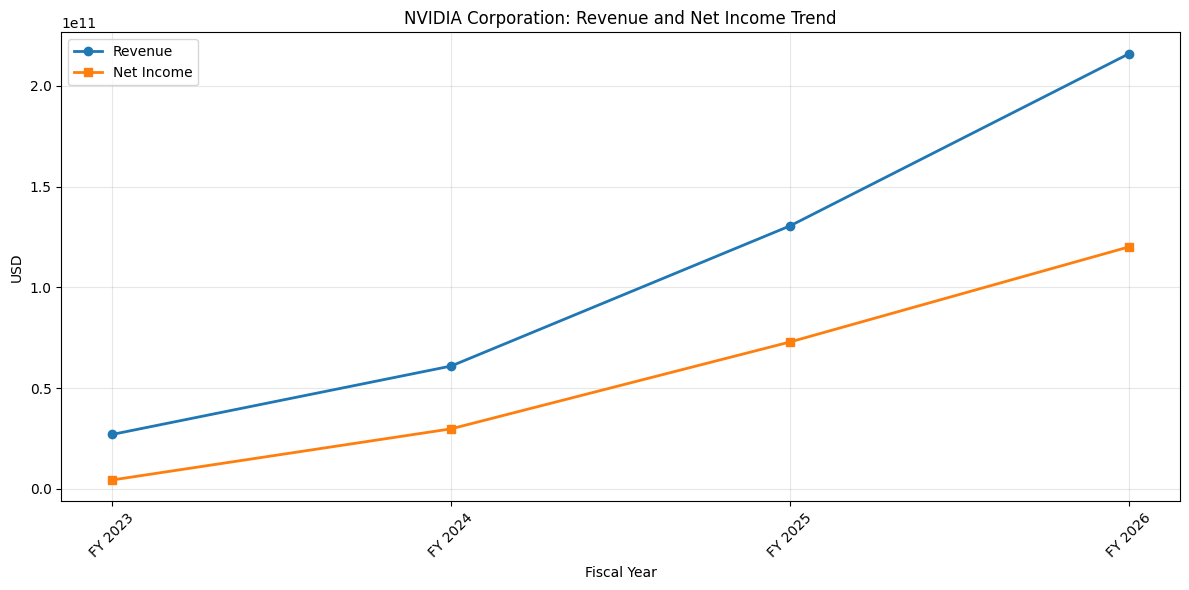

In [22]:
# Create revenue vs net income chart
income_data = %sql SELECT * FROM income_statement ORDER BY fiscal_year, fiscal_period
df = income_data.DataFrame()

fig, ax = plt.subplots(figsize=(12, 6))
x_labels = df['fiscal_year'].astype(str)
ax.plot(x_labels, df['revenue'], marker='o', label='Revenue', linewidth=2)
ax.plot(x_labels, df['net_income'], marker='s', label='Net Income', linewidth=2)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('USD')
ax.set_title(f'{company_name}: Revenue and Net Income Trend')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Running query in 'sqlite:///sec_financials.db'

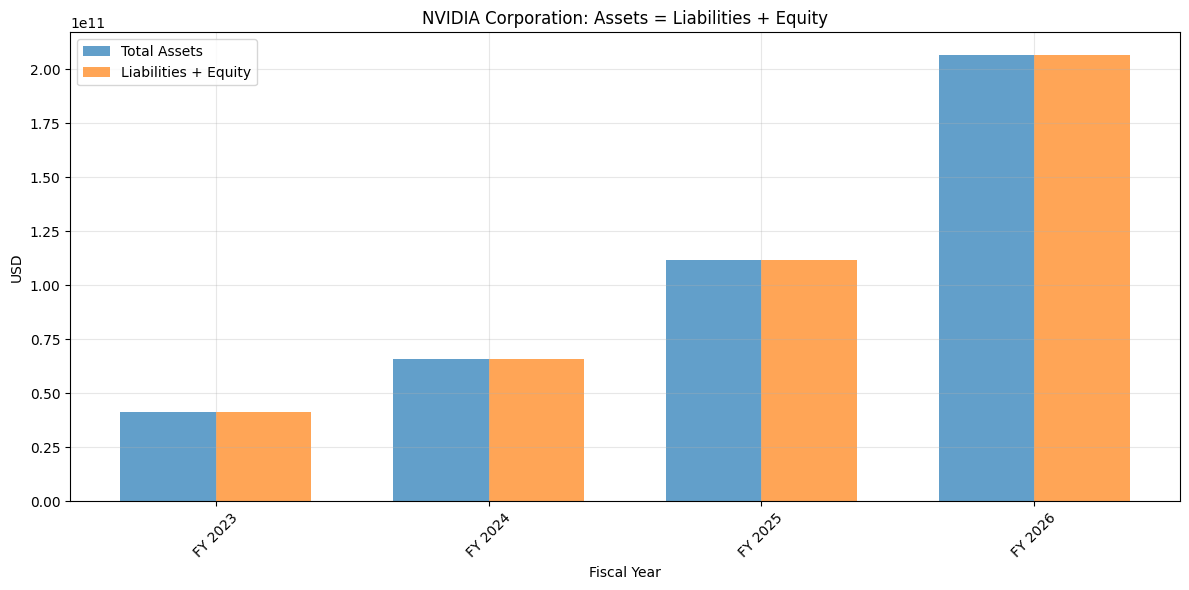

In [23]:
# Create balance sheet validation chart
bs_data = %sql SELECT * FROM balance_sheet WHERE total_assets IS NOT NULL ORDER BY fiscal_year, fiscal_period
df = bs_data.DataFrame()

x_labels = df['fiscal_year'].astype(str)
x = range(len(x_labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar([i - width/2 for i in x], df['total_assets'], width, label='Total Assets', alpha=0.7)
plt.bar([i + width/2 for i in x], df['total_liabilities'] + df['total_equity'], width, label='Liabilities + Equity', alpha=0.7)
plt.xlabel('Fiscal Year')
plt.ylabel('USD')
plt.title(f'{company_name}: Assets = Liabilities + Equity')
plt.xticks(x, x_labels, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()